
# Notebook 04 — Tree Models on Structured Features

## 0. Imports and configuration

In [1]:

import os
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 180)

CLEAN_DIR = "../dataset/cleaned"

TRAIN_FILE = os.path.join(
    CLEAN_DIR,
    "train_clean_experiment.csv"
)

TEST_FILE = os.path.join(
    CLEAN_DIR,
    "test_clean_experiment.csv"
)

ARTIFACT_DIR = "../artifacts/notebook_04"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

VALID_SIZE = 0.20
RANDOM_STATE = 42

USE_LOG_TARGET = True

N_ESTIMATORS = 800

EARLY_STOPPING_ROUNDS = 80

print("Configuration loaded.")


Configuration loaded.


## 1. Load cleaned data

In [2]:

train = pd.read_csv(TRAIN_FILE)
test = pd.read_csv(TEST_FILE)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

display(train.head(3))


Train shape: (193693, 27)
Test shape : (50000, 26)


,PRODUCT_ID,TITLE,BULLET_POINTS,DESCRIPTION,PRODUCT_TYPE_ID,PRODUCT_LENGTH,DIM_1_CM,DIM_2_CM,DIM_3_CM,DIM_COUNT,DIM_PRODUCT_2D_CM2,DIM_VOLUME_CM3,HAS_DIMENSION_2D,HAS_DIMENSION_3D,TITLE_CHAR_COUNT,TITLE_WORD_COUNT,TITLE_DIGIT_COUNT,TITLE_EMPTY,BULLET_CHAR_COUNT,BULLET_WORD_COUNT,BULLET_DIGIT_COUNT,BULLET_EMPTY,DESC_CHAR_COUNT,DESC_WORD_COUNT,DESC_DIGIT_COUNT,DESC_EMPTY,HAS_MEASUREMENT_UNIT
0,667259,Work-Life Balance and Women's Entrepreneurship: An Exploration of Influencing Factors (Contribut...,NaN,NaN,6046,614.000000,15.7,21.0,8.509,0,329.7,2805.4173,0,0,123,14,0,0,0,0,0,1,0,0,0,1,0
1,2519657,YES2GOOD Back Case Cover for Oppo K3 Smoke Cover Protective Shockproof Translucent Hybrid Matte ...,[[Matte Translucent Case]: Made by high quality translucent matte non-glossy hard back and soft ...,YES2GOOD Matte Finish Shockproof Hard Back and Side Soft Smoke Back Case Cover can be easily ins...,12064,787.401574,1.0,3.0,17.800,0,3.0,53.4000,0,0,155,23,2,0,862,133,0,0,629,98,1,0,1
2,2169829,"Lettre ouverte du golfe de gascogne : Quelques propos insolites sur la société, la culture et la...",NaN,NaN,1,590.551180,6.0,11.0,2.500,0,66.0,165.0000,0,0,112,20,0,0,0,0,0,1,0,0,0,1,0


## 2. Validate cleaned data

In [3]:

REQUIRED_TRAIN = [
    "PRODUCT_ID",
    "TITLE",
    "BULLET_POINTS",
    "DESCRIPTION",
    "PRODUCT_TYPE_ID",
    "PRODUCT_LENGTH"
]

REQUIRED_TEST = [
    "PRODUCT_ID",
    "TITLE",
    "BULLET_POINTS",
    "DESCRIPTION",
    "PRODUCT_TYPE_ID"
]

for col in REQUIRED_TRAIN:
    assert col in train.columns, f"Missing train column: {col}"

for col in REQUIRED_TEST:
    assert col in test.columns, f"Missing test column: {col}"

assert "PRODUCT_LENGTH" not in test.columns
assert train["PRODUCT_ID"].is_unique
assert test["PRODUCT_ID"].is_unique

assert train["PRODUCT_LENGTH"].notna().all()
assert np.isfinite(train["PRODUCT_LENGTH"]).all()
assert (train["PRODUCT_LENGTH"] > 0).all()

print("Validation PASSED.")


Validation PASSED.


## 3. Select structured features

In [4]:

FEATURES = [
    "PRODUCT_TYPE_ID",

    "DIM_1_CM",
    "DIM_2_CM",
    "DIM_3_CM",
    "DIM_PRODUCT_2D_CM2",
    "DIM_VOLUME_CM3",

    "HAS_DIMENSION_2D",
    "HAS_DIMENSION_3D",

    "TITLE_CHAR_COUNT",
    "TITLE_WORD_COUNT",
    "TITLE_DIGIT_COUNT",
    "TITLE_EMPTY",

    "BULLET_CHAR_COUNT",
    "BULLET_WORD_COUNT",
    "BULLET_DIGIT_COUNT",
    "BULLET_EMPTY",

    "DESC_CHAR_COUNT",
    "DESC_WORD_COUNT",
    "DESC_DIGIT_COUNT",
    "DESC_EMPTY",

    "HAS_MEASUREMENT_UNIT"
]

missing_features = [
    c for c in FEATURES
    if c not in train.columns
]

assert not missing_features, (
    f"Missing structured features: {missing_features}"
)

print("Number of structured features:", len(FEATURES))
display(pd.DataFrame({"feature": FEATURES}))


Number of structured features: 21


,feature
0,PRODUCT_TYPE_ID
1,DIM_1_CM
2,DIM_2_CM
3,DIM_3_CM
4,DIM_PRODUCT_2D_CM2
5,DIM_VOLUME_CM3
6,HAS_DIMENSION_2D
7,HAS_DIMENSION_3D
8,TITLE_CHAR_COUNT
9,TITLE_WORD_COUNT


## 4. Prepare feature matrices

In [5]:

X = train[FEATURES].copy()
X_test = test[FEATURES].copy()

y_raw = train["PRODUCT_LENGTH"].astype(np.float64).values

if USE_LOG_TARGET:
    y = np.log1p(y_raw)
else:
    y = y_raw

# Tree libraries can handle numeric values, but we make all features
# explicitly numeric and replace any unexpected infinities.
X = X.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

X = X.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Median imputation is fitted using training data only.
feature_medians = X.median()

X = X.fillna(feature_medians)
X_test = X_test.fillna(feature_medians)

print("X shape     :", X.shape)
print("X_test shape:", X_test.shape)
print("Missing X   :", X.isna().sum().sum())
print("Missing test:", X_test.isna().sum().sum())


X shape     : (193693, 21)
X_test shape: (50000, 21)
Missing X   : 0
Missing test: 0


## 5. Fixed train / validation split

In [6]:

indices = np.arange(len(train))

train_idx, valid_idx = train_test_split(
    indices,
    test_size=VALID_SIZE,
    random_state=RANDOM_STATE
)

X_train = X.iloc[train_idx].copy()
X_valid = X.iloc[valid_idx].copy()

y_train_raw = y_raw[train_idx]
y_valid_raw = y_raw[valid_idx]

y_train = y[train_idx]
y_valid = y[valid_idx]

print("Training rows  :", len(X_train))
print("Validation rows:", len(X_valid))


Training rows  : 154954
Validation rows: 38739


## 6. Evaluation functions

In [7]:

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    mask = (
        np.isfinite(y_true)
        & np.isfinite(y_pred)
        & (y_true != 0)
    )

    return np.mean(
        np.abs(
            (y_true[mask] - y_pred[mask])
            / y_true[mask]
        )
    ) * 100.0


def evaluate_model(name, y_true, y_pred):
    y_pred = np.asarray(y_pred, dtype=np.float64)

    # PRODUCT_LENGTH cannot be negative.
    y_pred = np.maximum(y_pred, 1e-6)

    result = {
        "model": name,
        "MAPE": mape(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        )
    }

    print(f"\n{name}")
    print("-" * len(name))
    print(f"MAPE : {result['MAPE']:.4f}%")
    print(f"MAE  : {result['MAE']:.4f}")
    print(f"RMSE : {result['RMSE']:.4f}")

    return result, y_pred


## 7. LightGBM

In [8]:

lightgbm_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=N_ESTIMATORS,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

lightgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    callbacks=[
        lgb.early_stopping(
            EARLY_STOPPING_ROUNDS,
            verbose=False
        )
    ]
)

pred_lgbm_model = lightgbm_model.predict(X_valid)

if USE_LOG_TARGET:
    pred_lgbm = np.expm1(pred_lgbm_model)
else:
    pred_lgbm = pred_lgbm_model

lgbm_result, pred_lgbm = evaluate_model(
    "LightGBM — Structured Features",
    y_valid_raw,
    pred_lgbm
)

print("Best iteration:", lightgbm_model.best_iteration_)



LightGBM — Structured Features
------------------------------
MAPE : 54.9122%
MAE  : 419.9893
RMSE : 924.9953
Best iteration: 798


## 8. XGBoost

In [9]:

xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=N_ESTIMATORS,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=10,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

pred_xgb_model = xgb_model.predict(X_valid)

if USE_LOG_TARGET:
    pred_xgb = np.expm1(pred_xgb_model)
else:
    pred_xgb = pred_xgb_model

xgb_result, pred_xgb = evaluate_model(
    "XGBoost — Structured Features",
    y_valid_raw,
    pred_xgb
)



XGBoost — Structured Features
-----------------------------
MAPE : 54.6627%
MAE  : 416.7258
RMSE : 920.2034


## 9. CatBoost

In [10]:

cat_model = CatBoostRegressor(
    loss_function="RMSE",
    iterations=N_ESTIMATORS,
    learning_rate=0.03,
    depth=7,
    l2_leaf_reg=5.0,
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False
)

cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    verbose=False
)

pred_cat_model = cat_model.predict(X_valid)

if USE_LOG_TARGET:
    pred_cat = np.expm1(pred_cat_model)
else:
    pred_cat = pred_cat_model

cat_result, pred_cat = evaluate_model(
    "CatBoost — Structured Features",
    y_valid_raw,
    pred_cat
)



CatBoost — Structured Features
------------------------------
MAPE : 56.6808%
MAE  : 431.8572
RMSE : 949.3984


## 10. Compare tree models

In [11]:

tree_results = pd.DataFrame([
    lgbm_result,
    xgb_result,
    cat_result
]).sort_values("MAPE").reset_index(drop=True)

display(tree_results)


,model,MAPE,MAE,RMSE
0,XGBoost — Structured Features,54.662717,416.725769,920.203421
1,LightGBM — Structured Features,54.912160,419.989254,924.995331
2,CatBoost — Structured Features,56.680824,431.857172,949.398396


## 11. Compare against Notebook 03 Ridge baseline

In [12]:

BASELINE_MAPE = 56.3653

comparison = tree_results.copy()

baseline_row = pd.DataFrame([{
    "model": "Ridge + Word TF-IDF — Notebook 03",
    "MAPE": BASELINE_MAPE,
    "MAE": np.nan,
    "RMSE": np.nan
}])

comparison = pd.concat(
    [baseline_row, comparison],
    ignore_index=True
).sort_values("MAPE").reset_index(drop=True)

display(comparison)


,model,MAPE,MAE,RMSE
0,XGBoost — Structured Features,54.662717,416.725769,920.203421
1,LightGBM — Structured Features,54.912160,419.989254,924.995331
2,Ridge + Word TF-IDF — Notebook 03,56.365300,NaN,NaN
3,CatBoost — Structured Features,56.680824,431.857172,949.398396


## 12. MAPE by target range

In [13]:

def mape_by_target_range(y_true, y_pred):

    y_true = np.asarray(y_true)
    y_pred = np.maximum(
        np.asarray(y_pred),
        1e-6
    )

    ranges = [
        ("54-100", 54, 100),
        ("101-200", 101, 200),
        ("201-500", 201, 500),
        ("501-1000", 501, 1000),
        ("1001-2000", 1001, 2000),
        ("2001-5000", 2001, 5000),
        ("5001+", 5001, np.inf)
    ]

    rows = []

    for label, low, high in ranges:

        mask = (
            (y_true >= low)
            & (y_true <= high)
        )

        if mask.sum() == 0:
            continue

        rows.append({
            "range": label,
            "count": int(mask.sum()),
            "percentage": float(mask.mean() * 100),
            "MAPE": float(
                mape(y_true[mask], y_pred[mask])
            )
        })

    return pd.DataFrame(rows)


model_predictions = {
    "LightGBM": pred_lgbm,
    "XGBoost": pred_xgb,
    "CatBoost": pred_cat
}

for name, pred in model_predictions.items():

    print("\n", "=" * 60)
    print(name)
    print("=" * 60)

    display(
        mape_by_target_range(
            y_valid_raw,
            pred
        )
    )



LightGBM


,range,count,percentage,MAPE
0,54-100,829,2.139962,609.398467
1,101-200,1281,3.306745,266.971119
2,201-500,6839,17.654044,73.972255
3,501-1000,19854,51.250678,18.408526
4,1001-2000,6992,18.048995,34.968862
5,2001-5000,2013,5.196314,54.178078
6,5001+,927,2.392937,58.906928



XGBoost


,range,count,percentage,MAPE
0,54-100,829,2.139962,610.972376
1,101-200,1281,3.306745,265.115382
2,201-500,6839,17.654044,73.168339
3,501-1000,19854,51.250678,18.435681
4,1001-2000,6992,18.048995,34.663762
5,2001-5000,2013,5.196314,53.923300
6,5001+,927,2.392937,57.879675



CatBoost


,range,count,percentage,MAPE
0,54-100,829,2.139962,641.269558
1,101-200,1281,3.306745,279.881034
2,201-500,6839,17.654044,75.670302
3,501-1000,19854,51.250678,18.549856
4,1001-2000,6992,18.048995,35.717092
5,2001-5000,2013,5.196314,55.950544
6,5001+,927,2.392937,61.347172


## 13. Select the best tree model

In [14]:

prediction_map = {
    "LightGBM — Structured Features": pred_lgbm,
    "XGBoost — Structured Features": pred_xgb,
    "CatBoost — Structured Features": pred_cat
}

best_tree_name = tree_results.iloc[0]["model"]
best_tree_prediction = prediction_map[best_tree_name]

print("Best tree model:", best_tree_name)
print("MAPE:", tree_results.iloc[0]["MAPE"])


Best tree model: XGBoost — Structured Features
MAPE: 54.66271653875647


## 14. Actual vs predicted for best tree model

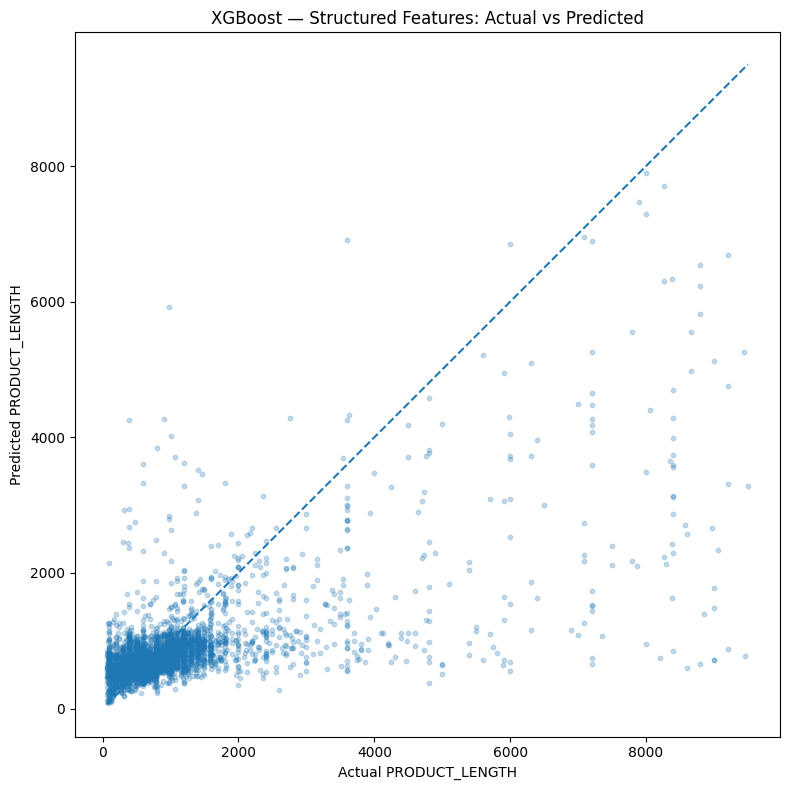

In [15]:

sample_size = min(5000, len(y_valid_raw))

rng = np.random.default_rng(RANDOM_STATE)

sample_idx = rng.choice(
    len(y_valid_raw),
    size=sample_size,
    replace=False
)

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    y_valid_raw[sample_idx],
    best_tree_prediction[sample_idx],
    alpha=0.25,
    s=10
)

low = min(
    y_valid_raw[sample_idx].min(),
    best_tree_prediction[sample_idx].min()
)

high = max(
    y_valid_raw[sample_idx].max(),
    best_tree_prediction[sample_idx].max()
)

ax.plot(
    [low, high],
    [low, high],
    linestyle="--"
)

ax.set_xlabel("Actual PRODUCT_LENGTH")
ax.set_ylabel("Predicted PRODUCT_LENGTH")
ax.set_title(
    f"{best_tree_name}: Actual vs Predicted"
)

plt.tight_layout()
plt.show()


## 15. Worst validation errors

In [16]:

error_df = train.iloc[valid_idx][
    [
        "PRODUCT_ID",
        "TITLE",
        "PRODUCT_TYPE_ID",
        "PRODUCT_LENGTH"
    ]
].copy()

error_df["prediction"] = best_tree_prediction

error_df["absolute_error"] = (
    np.abs(
        error_df["PRODUCT_LENGTH"]
        - error_df["prediction"]
    )
)

error_df["APE"] = (
    error_df["absolute_error"]
    / error_df["PRODUCT_LENGTH"]
) * 100

display(
    error_df
    .sort_values("APE", ascending=False)
    .head(50)
)


,PRODUCT_ID,TITLE,PRODUCT_TYPE_ID,PRODUCT_LENGTH,prediction,absolute_error,APE
74901,1706794,Kokka IRO Lei Nani Double Gauze Pink Fabric,8401,100.000000,3102.586670,3002.586670,3002.586670
111387,2061972,Nuha Rugs Shag Rug Beige and Ivory Color 5 cm Pile Height Modern Shaggy Carpet for Bedroom Home ...,1634,196.850393,5676.818848,5479.968454,2783.823978
40419,1176017,Philips 17304 Synthetic Wall Lighting (Black and Yellow),1667,66.929000,1866.406250,1799.477250,2688.636092
172305,1728720,Fabric Merchants California Stretch French Terry Denim Fabric,8401,100.000000,2620.426270,2520.426270,2520.426270
112011,1048263,"Trans Globe Lighting LED-CAB24 WH Indoor Signature 24"" Undercabinet, White",1667,100.000000,2139.692627,2039.692627,2039.692627
108471,1967971,"Kingdom High Density Artificial Grass Mat (Pure Green, 3.3 Feet x 2 Feet)",7287,118.110236,2522.819092,2404.708856,2035.986833
122086,2374884,"Drywall Patch, Wall Mending Agent,Drywall Repair Cream,Wall Surface Repair, Quick & Easy Solutio...",8417,86.614173,1831.746216,1745.132043,2014.834270
171191,1987788,JAIJY Black Tassels Drapes Arrow Vertical Striped Printting Cotton Linen Fabric Rod Pocket Windo...,1649,200.000000,4111.231445,3911.231445,1955.615723
99092,1364077,Hanes Serenity Blackout Drapery Black Fabric By The Yard,8401,100.000000,1923.903564,1823.903564,1823.903564
25033,906909,EREPLACEMENTS SP-LAMP-008-ER eReplacements SP-LAMP-008 - Projector lamp - for InFocus LP 790,6888,66.929000,1284.053955,1217.124955,1818.531511


## 16. LightGBM feature importance

,feature,importance
0,PRODUCT_TYPE_ID,3670
2,DIM_2_CM,2106
1,DIM_1_CM,2066
3,DIM_3_CM,1983
12,BULLET_CHAR_COUNT,1563
5,DIM_VOLUME_CM3,1462
4,DIM_PRODUCT_2D_CM2,1442
13,BULLET_WORD_COUNT,1377
8,TITLE_CHAR_COUNT,1352
10,TITLE_DIGIT_COUNT,1233


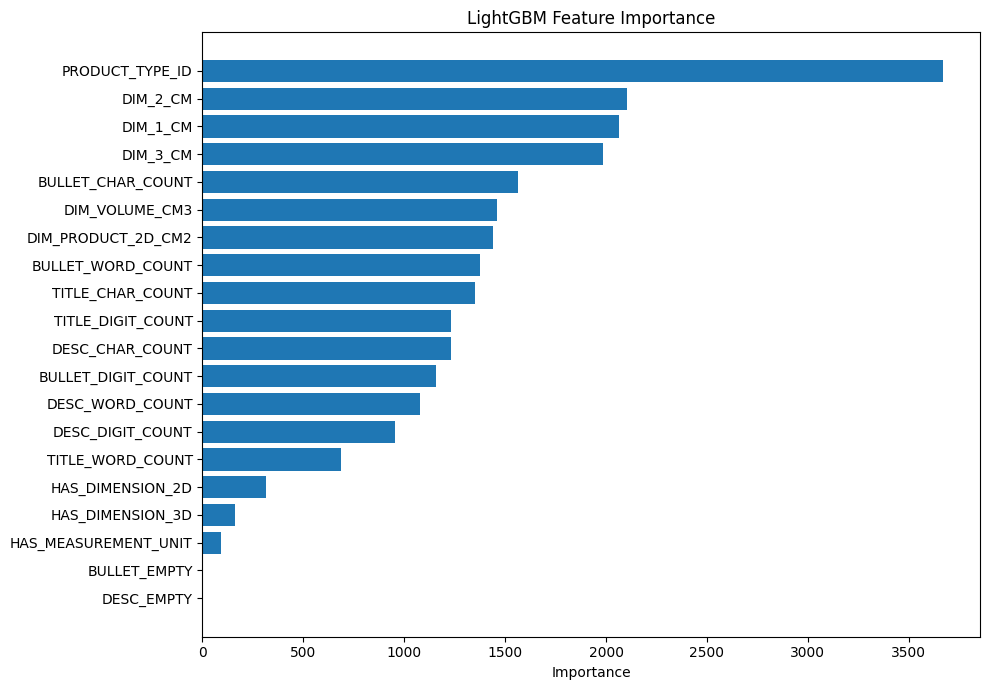

In [17]:

lgbm_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": lightgbm_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(lgbm_importance)

top_n = min(20, len(lgbm_importance))

fig, ax = plt.subplots(figsize=(10, 7))

plot_data = lgbm_importance.head(top_n).sort_values("importance")

ax.barh(
    plot_data["feature"],
    plot_data["importance"]
)

ax.set_title("LightGBM Feature Importance")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()


## 17. XGBoost feature importance

In [18]:

xgb_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": xgb_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(xgb_importance)


,feature,importance
4,DIM_PRODUCT_2D_CM2,0.180680
2,DIM_2_CM,0.115203
6,HAS_DIMENSION_2D,0.092228
0,PRODUCT_TYPE_ID,0.074103
3,DIM_3_CM,0.064966
15,BULLET_EMPTY,0.064857
5,DIM_VOLUME_CM3,0.051567
19,DESC_EMPTY,0.046758
1,DIM_1_CM,0.044924
7,HAS_DIMENSION_3D,0.037058


## 18. CatBoost feature importance

In [19]:

cat_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": cat_model.get_feature_importance()
}).sort_values(
    "importance",
    ascending=False
)

display(cat_importance)


,feature,importance
0,PRODUCT_TYPE_ID,25.705723
2,DIM_2_CM,13.950723
3,DIM_3_CM,12.757739
4,DIM_PRODUCT_2D_CM2,9.928985
1,DIM_1_CM,8.697048
5,DIM_VOLUME_CM3,4.415446
14,BULLET_DIGIT_COUNT,3.582221
10,TITLE_DIGIT_COUNT,3.265908
6,HAS_DIMENSION_2D,3.189164
13,BULLET_WORD_COUNT,2.874533


## 19. Save validation predictions

In [20]:

validation_predictions = train.iloc[valid_idx][
    [
        "PRODUCT_ID",
        "PRODUCT_TYPE_ID",
        "PRODUCT_LENGTH"
    ]
].copy()

validation_predictions["prediction"] = best_tree_prediction

validation_predictions["APE"] = (
    np.abs(
        validation_predictions["PRODUCT_LENGTH"]
        - validation_predictions["prediction"]
    )
    / validation_predictions["PRODUCT_LENGTH"]
) * 100

prediction_file = os.path.join(
    ARTIFACT_DIR,
    "validation_predictions_best_tree.csv"
)

validation_predictions.to_csv(
    prediction_file,
    index=False
)

print("Saved:", prediction_file)


Saved: ../artifacts/notebook_04\validation_predictions_best_tree.csv


## 20. Save models

In [21]:

joblib.dump(
    lightgbm_model,
    os.path.join(
        ARTIFACT_DIR,
        "lightgbm_structured.joblib"
    )
)

joblib.dump(
    xgb_model,
    os.path.join(
        ARTIFACT_DIR,
        "xgboost_structured.joblib"
    )
)

joblib.dump(
    cat_model,
    os.path.join(
        ARTIFACT_DIR,
        "catboost_structured.joblib"
    )
)

joblib.dump(
    feature_medians,
    os.path.join(
        ARTIFACT_DIR,
        "feature_medians.joblib"
    )
)

print("Models saved to:", ARTIFACT_DIR)


Models saved to: ../artifacts/notebook_04


## 21. Save experiment configuration

In [22]:

config = {
    "train_file": TRAIN_FILE,
    "test_file": TEST_FILE,
    "validation_size": VALID_SIZE,
    "random_state": RANDOM_STATE,
    "use_log_target": USE_LOG_TARGET,
    "n_estimators": N_ESTIMATORS,
    "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
    "features": FEATURES,
    "results": tree_results.to_dict(orient="records"),
    "ridge_word_tfidf_baseline_mape": BASELINE_MAPE
}

config_file = os.path.join(
    ARTIFACT_DIR,
    "experiment_config.json"
)

with open(config_file, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("Saved:", config_file)


Saved: ../artifacts/notebook_04\experiment_config.json



# Notebook 04 Complete

You now have a fair comparison between:

```text
Ridge + Word TF-IDF
        56.3653% MAPE
             │
             ▼
    Structured Tree Models
       ├── LightGBM
       ├── XGBoost
       └── CatBoost
```

## What to report after running

Send the three outputs:

```text
LightGBM MAPE  = ?
XGBoost MAPE   = ?
CatBoost MAPE  = ?
```

Then we will choose the strongest tree model and build the next stage:

```text
TF-IDF NLP
    +
Structured Features
    +
Best Tree Model
        ↓
Hybrid Model
```

Do not change the validation split or Notebook 02 cleaning rules while making this comparison.
